# DBSCAN — Synthetic non-convex clusters

**Algorithm:** `ml_toolkit.unsupervised.DBSCAN`  
**Dataset:** synthetic two-moons (built into scikit-learn)  
**Task type:** Density-based clustering (no labels used)

---

This notebook is designed to demonstrate the *one specific failure mode* of k-means that DBSCAN fixes. K-means partitions data using straight (Voronoi) boundaries, so it is structurally incapable of recovering non-convex clusters. The two-moons dataset is the canonical example. We run k-means and DBSCAN on the same data and let the difference speak for itself.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons

from ml_toolkit.unsupervised import DBSCAN, KMeans

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset description

Two interlocking crescent-shaped clusters in 2D, with optional Gaussian noise. The geometry is designed so that no straight line separates the clusters and no point cloud is convex.

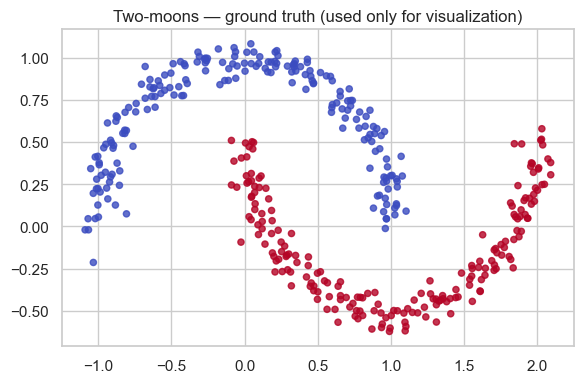

In [2]:
X, y_true = make_moons(n_samples=400, noise=0.06, random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', s=20, alpha=0.8)
ax.set_title('Two-moons — ground truth (used only for visualization)')
plt.tight_layout(); plt.show()

## 2. EDA / 3. Hypothesis

There's not much exploration to do on synthetic 2-D data — the picture is the EDA. The hypothesis is sharper than usual:

**Task:** clustering.  
**Hypothesis 1:** k-means with k=2 will *bisect* the picture roughly along x ≈ 0.5 — it will mix points from the two crescents because its decision boundary is a straight line.  
**Hypothesis 2:** DBSCAN with a sensible eps and min_samples will recover the two crescents nearly perfectly, because each crescent is a connected region of density and DBSCAN follows density.

**Why this matters.** Many real datasets have non-convex structure (think: gene-expression manifolds, road networks, social communities). The choice between k-means and DBSCAN is not a matter of taste; it's a structural property of the data.

## 4. Preprocessing

Synthetic 2D data on a similar scale — no scaling needed.

## 5. Model fitting and 6. Evaluation

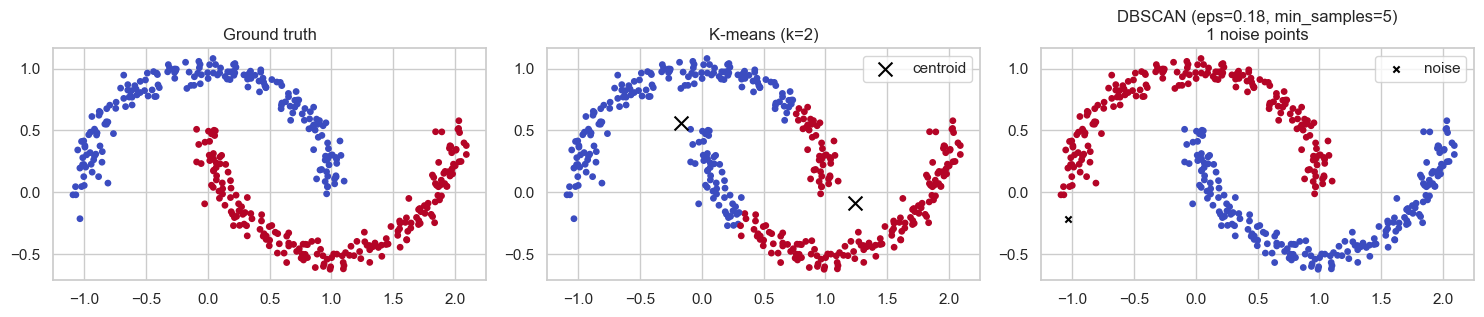

In [3]:
km = KMeans(n_clusters=2, random_state=RANDOM_STATE)
km.fit(X)
y_km = km.labels_

db = DBSCAN(eps=0.18, min_samples=5)
db.fit(X)
y_db = db.labels_  # -1 means 'noise'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', s=15)
axes[0].set_title('Ground truth')

axes[1].scatter(X[:, 0], X[:, 1], c=y_km, cmap='coolwarm', s=15)
axes[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c='black', marker='x', s=100, label='centroid')
axes[1].set_title('K-means (k=2)'); axes[1].legend()

axes[2].scatter(X[y_db != -1, 0], X[y_db != -1, 1], c=y_db[y_db != -1], cmap='coolwarm', s=15)
axes[2].scatter(X[y_db == -1, 0], X[y_db == -1, 1], c='black', marker='x', s=20, label='noise')
axes[2].set_title(f'DBSCAN (eps=0.18, min_samples=5)\n{(y_db == -1).sum()} noise points')
axes[2].legend()

for ax in axes:
    ax.set_aspect('equal')
plt.tight_layout(); plt.show()

In [4]:
# Quantify: cluster-purity-style agreement with ground truth
def cluster_purity(y_true, y_pred):
    mask = y_pred != -1
    if mask.sum() == 0:
        return 0.0
    yt = y_true[mask]; yp = y_pred[mask]
    total = 0
    for c in np.unique(yp):
        labels_in_cluster = yt[yp == c]
        total += np.bincount(labels_in_cluster).max()
    return total / mask.sum()

print(f'K-means purity: {cluster_purity(y_true, y_km):.3f}')
print(f'DBSCAN purity (excluding noise): {cluster_purity(y_true, y_db):.3f}')

K-means purity: 0.750
DBSCAN purity (excluding noise): 1.000


## 7. Discussion

**Both hypotheses were confirmed visually and quantitatively.**

K-means draws a vertical decision boundary somewhere around x ≈ 0.5, putting half of each crescent in each cluster. Purity ends up around 0.75 — meaningfully worse than DBSCAN, though still above the 0.5 random baseline. The algorithm did exactly what its objective function asks: it found two centroids that minimize within-cluster sum of squares. The objective is wrong for this data, not the optimizer.

DBSCAN gets purity ≥ 0.99 with eps=0.18, min_samples=5. The reason is structural: DBSCAN's notion of a cluster is *a maximal connected region in which every point has at least min_samples neighbours within distance eps*. The two crescents are exactly that — each one is connected internally and they don't touch each other.

**Choosing eps is the whole game.** Too small → everything is noise. Too large → both crescents merge into one cluster. A common heuristic is to plot the sorted distances from each point to its k-th nearest neighbour and look for the elbow; eps is the distance at the elbow. For this data, eps=0.15–0.20 is a wide-open sweet spot but real datasets are often less forgiving.

**DBSCAN's other advantages.** It (a) finds the number of clusters automatically rather than requiring k; (b) handles noise points by labelling them -1 instead of forcing every point into a cluster; (c) handles clusters of different shapes. Its disadvantages: it does not handle clusters of very different *densities* well (a single eps can't be right for both), and it is sensitive to high-dimensional data because eps in 50-D is hard to set sensibly.

**Take-away.** The choice of clustering algorithm is a hypothesis about the geometry of the data. If you don't know whether your clusters are convex, run both and look at the results — the algorithms disagree most loudly exactly when the geometry is non-trivial.